In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('water_disease_data.csv')

In [ ]:
df.head()

,pH,Turbidity,Temperature,Conductivity,TDS,Hardness,Weather,Location,Disease
0,6.19,209.75,15.55,802.67,387.88,422.38,Cloudy,Lucknow,Cholera
1,8.78,161.29,26.26,744.81,371.68,394.04,Sunny,Delhi,Cholera
2,7.79,93.55,36.19,87.18,1096.88,308.09,Humid,Hyderabad,Diarrhea
3,7.19,244.32,31.97,544.81,374.50,480.22,Cloudy,Hyderabad,Cholera
4,5.20,205.73,34.20,601.28,399.14,140.21,Rainy,Chennai,Cholera


In [ ]:
df.isnull()

,pH,Turbidity,Temperature,Conductivity,TDS,Hardness,Weather,Location,Disease
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False


In [ ]:
features=['pH','Turbidity','Temperature','Conductivity','TDS','Hardness','Weather','Location']
target=['Disease']

In [ ]:
print(target)

['Disease']


In [ ]:
print(features)

['pH', 'Turbidity', 'Temperature', 'Conductivity', 'TDS', 'Hardness', 'Weather', 'Location']


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le_target = LabelEncoder()
df['Disease_Encoded'] = le_target.fit_transform(df['Disease'])

In [ ]:
le_location = LabelEncoder()
df['Location_Encoded'] = le_location.fit_transform(df['Location'])

In [ ]:
le_Weather = LabelEncoder()
df['Weather_Encoded'] = le_Weather.fit_transform(df['Weather'])

In [ ]:
le_target,le_Weather,le_location

(LabelEncoder(), LabelEncoder(), LabelEncoder())

In [ ]:
X = df[['pH', 'Turbidity', 'Hardness', 'Conductivity', 'Location_Encoded','Weather_Encoded']]
y = df['Disease_Encoded']

In [ ]:
X.head()

,pH,Turbidity,Hardness,Conductivity,Location_Encoded,Weather_Encoded
0,6.19,209.75,422.38,802.67,7,0
1,8.78,161.29,394.04,744.81,3,4
2,7.79,93.55,308.09,87.18,4,1
3,7.19,244.32,480.22,544.81,4,0
4,5.20,205.73,140.21,601.28,2,2


In [ ]:
y.head()


,Disease_Encoded
0,0
1,0
2,1
3,0
4,0


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
## train and test the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,pH,Turbidity,Hardness,Conductivity,Location_Encoded,Weather_Encoded
249,8.34,187.65,336.18,248.81,1,1
433,4.96,158.18,295.02,925.06,5,0
19,5.81,45.97,375.22,1394.20,8,4
322,7.47,100.72,335.46,941.77,1,1
332,4.56,43.12,103.33,894.51,7,4
...,...,...,...,...,...,...
106,6.35,62.69,71.08,148.04,3,0
270,8.14,34.08,84.31,716.20,3,2
348,6.19,151.16,303.83,1336.04,6,2
435,7.65,82.42,125.29,1217.23,3,2


In [ ]:

print(X.shape,X_test.shape,X_train.shape)


(500, 6) (100, 6) (400, 6)


In [ ]:
print(y.shape,y_test.shape,y_train.shape)

(500,) (100,) (400,)


In [ ]:
num_features = ['pH', 'Turbidity', 'Hardness',  'Conductivity']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
scld_df = scaler.fit_transform(X[num_features])

In [ ]:
scld_df

array([[0.3752809 , 0.69694831, 0.82931338, 0.51838967],
       [0.95730337, 0.53407945, 0.76619674, 0.4782907 ],
       [0.73483146, 0.30641258, 0.57477562, 0.02253055],
       ...,
       [0.0741573 , 0.13285609, 0.31043852, 0.06606003],
       [0.97977528, 0.95025879, 0.29066168, 0.05409826],
       [0.99325843, 0.44357061, 0.87332131, 0.28033238]])

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scaler =StandardScaler()
X_train_sclaed=scaler.fit_transform(X_train)
X_test_sclaed=scaler.transform(X_test)

In [ ]:
X_train_sclaed

array([[ 1.16642745,  0.47187539,  0.449544  , -1.27838659, -1.23459835,
        -0.71433106],
       [-1.33986592,  0.1282139 ,  0.13754517,  0.33909046,  0.15944354,
        -1.40785637],
       [-0.70958504, -1.18031192,  0.74547292,  1.46119498,  1.20497496,
         1.36624485],
       ...,
       [-0.42781241,  0.04635086,  0.20432626,  1.32208598,  0.50795401,
        -0.02080576],
       [ 0.65478768, -0.75525385, -1.1490331 ,  1.0379123 , -0.5375774 ,
        -0.02080576],
       [-0.63543435, -1.08748717,  0.83393323, -0.967831  , -0.88608787,
         1.36624485]])

In [ ]:
X_test_sclaed

array([[ 0.46199588, -0.12425544, -0.75615411,  0.52175474, -1.58310882,
        -0.71433106],
       [ 1.04037127,  0.46429548, -0.09455892,  1.23841966, -0.5375774 ,
        -1.40785637],
       [-1.44367688, -1.6162151 ,  0.94210192,  0.78755914, -0.88608787,
         0.67271954],
       [-0.87271656, -1.25984268, -0.29899547,  1.49561346,  0.85646448,
         1.36624485],
       [ 1.34438911, -1.28409839, -1.71928752, -1.513145  ,  0.85646448,
        -0.71433106],
       [-0.54645352,  0.62475636, -1.20262474,  0.1712077 ,  1.55348543,
        -1.40785637],
       [-1.60680841,  0.59280412, -1.02153504,  0.00916102, -1.23459835,
         0.67271954],
       [-0.91720698,  0.45100148, -0.43270925, -1.14592688,  0.85646448,
         0.67271954],
       [-1.42884675,  1.44781805,  1.02101125,  0.40974521, -0.18906693,
        -0.02080576],
       [ 0.9143151 ,  0.38907944,  1.10295263, -1.44662812, -1.58310882,
        -0.02080576],
       [ 0.68444796,  0.8256823 ,  1.32664275,  0.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,   # number of trees
    max_depth=15,       # tree depth
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=300, random_state=42)

In [ ]:
y_train_pred = rf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

In [ ]:
print("Training accuracy: ",(train_accuracy ))

Training accuracy:  1.0


In [ ]:
y_test_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [ ]:
print("Testing Accuracy: ",(test_accuracy ))

Testing Accuracy:  0.85


In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_target.classes_))


Classification Report:
               precision    recall  f1-score   support

     Cholera       0.98      1.00      0.99        60
    Diarrhea       0.33      0.14      0.20         7
 Hepatitis A       0.00      0.00      0.00         2
  No Disease       0.68      0.88      0.77        26
     Typhoid       1.00      0.20      0.33         5

    accuracy                           0.85       100
   macro avg       0.60      0.45      0.46       100
weighted avg       0.84      0.85      0.83       100



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

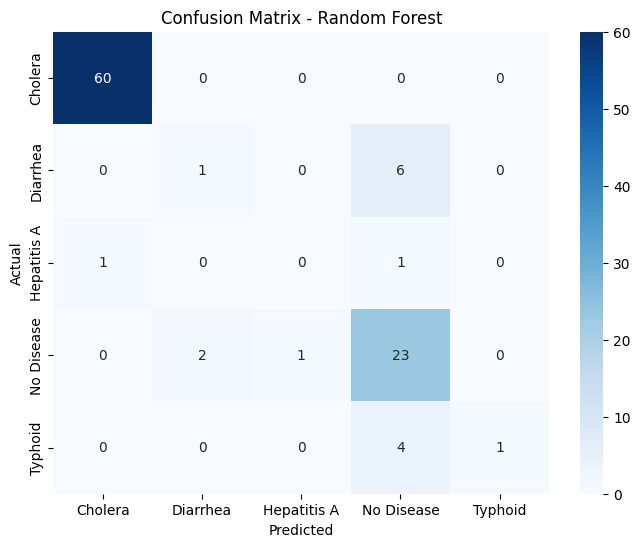

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
import pickle
with open('Water borne diseases prediction_model.pkl','wb') as f:
  pickle.dump(rf,f)

In [ ]:
import joblib
joblib.dump(rf, 'model.joblib')

['model.joblib']